# SGD size-200 empirical calibration

This notebook produces three figures from the saved results: service value by reasoning depth, cost-based service-time histograms, and service value versus mean service time. It runs entirely offline and makes no API calls.

We use the final completed response for each of the 200 requests at each of the five depths. Service value is the mean of `resolved_strict_exact`. Failed attempts are excluded; completed responses with incorrect predictions are still included in the service-time distributions.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from sgd_calibration import load_calibration

# Use the queue study's saved size-200 data; set this notebook's time scale below.
calibration = load_calibration(proxy="cost")
EFFORTS = list(calibration["efforts"])
strict_outcomes = calibration["outcomes"]
costs_usd = calibration["costs"]

assert strict_outcomes.shape == costs_usd.shape == (200, len(EFFORTS))
service_values = strict_outcomes.mean(axis=0)

# One common conversion factor across all requests AND all five depths.
TARGET_MEAN_SERVICE_TIME = 1.0
COST_TO_SERVICE_TIME = TARGET_MEAN_SERVICE_TIME / costs_usd.mean()
service_times = COST_TO_SERVICE_TIME * costs_usd

FIGURE_DIR = Path("results")
COLORS = ["#4c78a8", "#59a14f", "#f28e2b", "#e15759", "#7a5195"]

print(f"Cost-to-time coefficient: {COST_TO_SERVICE_TIME:.6f} normalized units/USD")
print(f"Pooled mean service time: {service_times.mean():.6f}")


Cost-to-time coefficient: 464.620281 normalized units/USD
Pooled mean service time: 1.000000


## 1. Service value by reasoning depth

The curve shows the empirical point estimates
\[
V(x_k)=\frac{1}{200}\sum_{j=1}^{200}Y_{jk},
\]
where \(Y_{jk}=1\) only when the request state is recovered correctly under the strict criterion. The line connects the five discrete depth choices; it does not represent additional available depths.


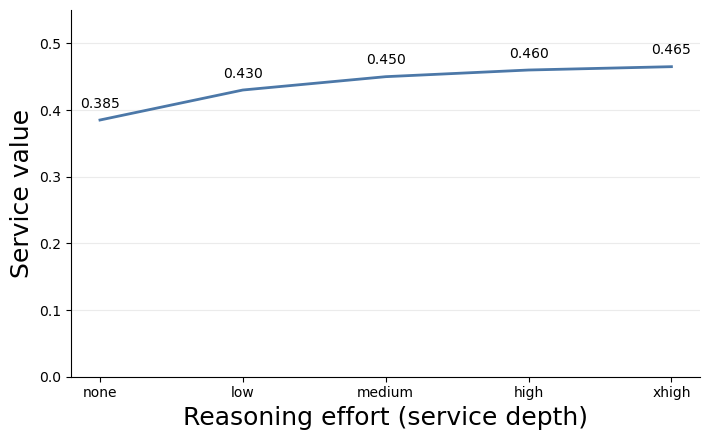

In [2]:
figure, axis = plt.subplots(figsize=(7.2, 4.5))
positions = np.arange(len(EFFORTS))

axis.plot(positions, service_values, color=COLORS[0], linewidth=2)
for position, value in zip(positions, service_values):
    axis.annotate(
        f"{value:.3f}", (position, value),
        xytext=(0, 9), textcoords="offset points", ha="center",
    )

axis.set_xticks(positions, EFFORTS)
axis.set_xlabel("Reasoning effort (service depth)",fontsize=18)
axis.set_ylabel("Service value",fontsize=18)
axis.set_ylim(0, 0.55)
axis.grid(axis="y", alpha=0.25)
axis.spines[["top", "right"]].set_visible(False)
figure.tight_layout()
figure.savefig(
    FIGURE_DIR / "sgd_size200_strict_accuracy.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## 2. Cost-based service-time distributions

Let \(C_{jk}\) be the logged `estimated_cost_usd` for the completed response to request \(j\) at depth \(k\). Define
\[
S_{jk}=\kappa C_{jk},\qquad
\kappa=\left(\frac{1}{200\times5}\sum_{j=1}^{200}\sum_{k=0}^{4}C_{jk}\right)^{-1}.
\]
The current target pooled mean service time is 1, controlled by `TARGET_MEAN_SERVICE_TIME` in the loading cell. We do **not** normalize each depth separately, so differences in average resource requirements are preserved. These are cost-based service requirements in normalized units, not measured seconds. This notebook's scale does not change the separate queue experiments.

The five panels share the same bins and axes and include every observation, including the longest service requirements. Change `SERVICE_TIME_BIN_WIDTH` below to adjust the bins.


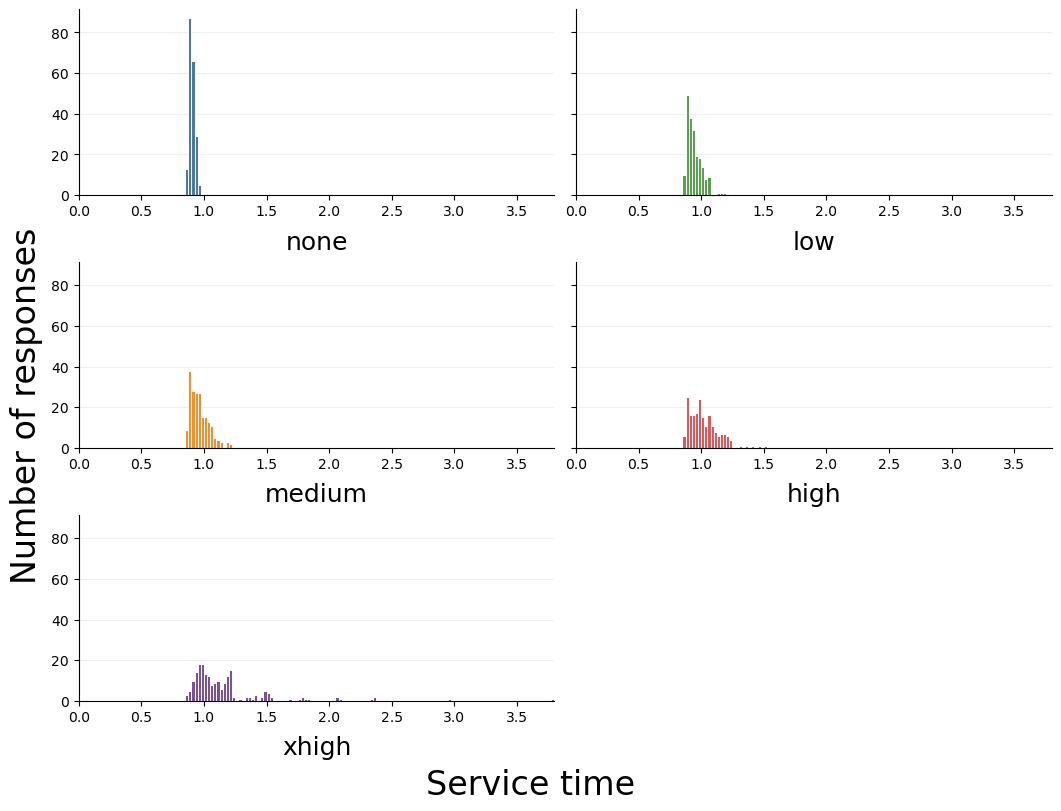

In [ ]:
# Scale bins with the time units to preserve the previous histogram detail.
SERVICE_TIME_BIN_WIDTH = 0.025 * TARGET_MEAN_SERVICE_TIME
axis_max = (
    np.ceil(service_times.max() / SERVICE_TIME_BIN_WIDTH)
    * SERVICE_TIME_BIN_WIDTH
)
bin_edges = np.linspace(
    0, axis_max, int(round(axis_max / SERVICE_TIME_BIN_WIDTH)) + 1,
)

figure, axes = plt.subplots(
    3, 2, figsize=(10.5, 8.0), sharex=True, sharey=True,
    layout="constrained",
)
axes = axes.ravel()

for column, (effort, color) in enumerate(zip(EFFORTS, COLORS)):
    axis = axes[column]
    axis.hist(
        service_times[:, column],
        bins=bin_edges,
        color=color,
        edgecolor="white",
        linewidth=0.7,
    )
    axis.set_xlabel(effort, fontsize=18, labelpad=8)
    axis.set_xlim(0, axis_max)
    axis.tick_params(axis="x", labelbottom=True)
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)

axes[-1].set_visible(False)
figure.supxlabel("Service time", fontsize=24)
figure.supylabel("Number of responses", fontsize=24)
figure.savefig(
    FIGURE_DIR / "sgd_size200_service_time_histograms.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


## 3. Service value versus mean service time

For each reasoning depth, the x-coordinate is its mean cost-based service time over the 200 completed responses, and the y-coordinate is its strict-resolution rate. The no-service option is shown at (0, 0): it uses no service time and earns no service value. This is distinct from the model's `none` reasoning effort, which still incurs cost and can resolve requests. No service is added only to this figure, not to the empirical averages or time normalization. The connecting line is only a visual guide, not a fitted value function.


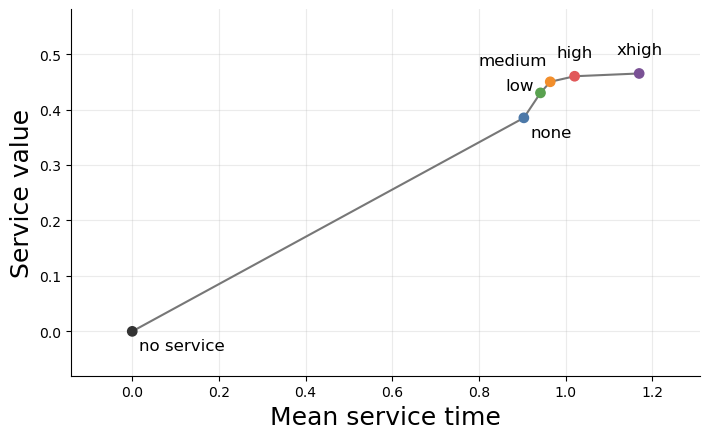

In [39]:
mean_service_times = service_times.mean(axis=0)
plot_times = np.r_[0.0, mean_service_times]
plot_values = np.r_[0.0, service_values]
plot_labels = ["no service", *EFFORTS]
plot_colors = ["#333333", *COLORS]

figure, axis = plt.subplots(figsize=(7.2, 4.5))
axis.plot(
    plot_times, plot_values,
    color="#777777", linewidth=1.5, zorder=1,
)
axis.scatter(
    plot_times, plot_values,
    c=plot_colors, s=45, zorder=2,
)
# Offsets are in points; connectors identify the tightly clustered depths.
label_positions = {
    "no service": ((5, -5), "left", "top"),
    "none": ((5, -5), "left", "top"),
    "low": ((-5, 5), "right", "center"),
    "medium": ((-2, 10), "right", "bottom"),
    "high": ((0, 12), "center", "bottom"),
    "xhigh": ((0, 12), "center", "bottom"),
}
for label, mean_time, value in zip(
    plot_labels, plot_times, plot_values,
):
    offset, horizontal, vertical = label_positions[label]
    axis.annotate(
        label, (mean_time, value),
        xytext=offset, textcoords="offset points",
        ha=horizontal, va=vertical, fontsize=12,
    )

axis.set_xlabel("Mean service time", fontsize=18)
axis.set_ylabel("Service value", fontsize=18)
axis.margins(x=0.12, y=0.25)
axis.set_ylim(bottom=-0.08)  # Space for the no-service label below the origin.
axis.grid(alpha=0.25)
axis.set_axisbelow(True)
axis.spines[["top", "right"]].set_visible(False)
figure.tight_layout()
figure.savefig(
    FIGURE_DIR / "sgd_size200_value_vs_mean_service_time.png",
    dpi=300, bbox_inches="tight",
)
plt.show()
